# <span style="color:rgb(213,80,0)">ROZWIĄZYWANIE UKŁADÓW RÓWNAŃ LINIOWYCH</span>

## Problem złożoności obliczeniowej i dokładności rozwiązania

Poniższy program generuje układy równań i rozwiązuje je dwoma metodami — rozkładem LU oraz rozkładem QR. Wyświetlane są wykresy czasu wykonania w zależności od rozmiaru układu (*estymata złożoności obliczeniowej*) oraz błędu rozwiązania.

Analizujemy dwa rodzaje macierzy:

1. **Macierz losowa** — współczynniki z rozkładu jednostajnego, wektor ***b*** jako suma wierszy macierzy ***A*** (rozwiazanie: wektor jedynek).
2. **Macierz Wilkinsona** — macierz tridiagonalna z diagonalą $[n, n-1, \dots, 2, 1]$ i $-1$ nad oraz pod przekątną główną.

**UWAGA!** Miarą złożoności jest czas pracy procesora, który może być zakłócany przez działający system operacyjny (przełączanie wątków itp.).

Dodatkowo należy pamiętać o różnicy między faktyczną złożonością a klasą złożoności.

**UWAGA!** Poniższe obliczenia mogą trwać do ~30s. Wszystkie dane używają `float64`.

Na wykresie:

- **QR** — czas/błąd dla pełnej metody QR wraz z rozkładem
- **LU** — czas/błąd dla pełnej metody LU wraz z rozkładem
- **Rozwiązanie** — czas samego rozwiązania bez kroku rozkładu


In [1]:
import numpy as np
import time

def solveUsingQRFactorization(A, b):
    time1 = time.perf_counter()
    Q, R = np.linalg.qr(A)
    time2 = time.perf_counter()
    y = Q.T @ b
    x = np.linalg.solve(R, y)
    time2end = time.perf_counter() - time2
    time1end = time.perf_counter() - time1
    error = np.linalg.norm(x - np.ones(len(b))) / np.linalg.norm(np.ones(len(b)))
    return time1end, time2end, error


def solveUsingLUFactorization(A, b):
    time1 = time.perf_counter()
    from scipy.linalg import lu_factor, lu_solve
    lu_pivots = lu_factor(A)
    time2 = time.perf_counter()
    x = lu_solve(lu_pivots, b)
    time2end = time.perf_counter() - time2
    time1end = time.perf_counter() - time1
    error = np.linalg.norm(x - np.ones(len(b))) / np.linalg.norm(np.ones(len(b)))
    return time1end, time2end, error


def wilkinson(n):
    """Zwraca macierz Wilkisona rozmiaru n×n.
    Macierz tridiagonalna z przekątną diagonal = [n, n-1, ..., 2, 1] i po -1 nad/pod przekątną."""
    A = np.diag(np.arange(n, 0, -1), 0) + np.diag(-np.ones(n-1), 1) + np.diag(-np.ones(n-1), -1)
    return A.astype(np.float64)


In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

np.random.seed(42)
Nmax = 300
step = 20

bladQR = []; bladLU = []
zlozonoscQR = []; zlozonoscLU = []
zlozonoscRozwQR = []; zlozonoscRozwLU = []
sizes = []

print("Rozwiązywanie... (to może trwać ~30s, zależy od sprzętu)")
T0 = time.perf_counter()
for i in range(4, Nmax + 1, step):
    A = np.random.rand(i, i).astype(np.float64)
    b = A.sum(axis=1).astype(np.float64)
    time_all_qr, time_simple_qr, error_qr = solveUsingQRFactorization(A, b)
    bladQR.append(error_qr)
    zlozonoscRozwQR.append(time_simple_qr)
    zlozonoscQR.append(time_all_qr)
    sizes.append(i)
    time_all_lu, time_simple_lu, error_lu = solveUsingLUFactorization(A, b)
    bladLU.append(error_lu)
    zlozonoscLU.append(time_all_lu)
    zlozonoscRozwLU.append(time_simple_lu)
    if i % 10 == 0:
        elapsed = time.perf_counter() - T0
        print(f"  N={i:4d}/{Nmax}  ({elapsed:.1f}s)")

print(f"Gotowe! Całkowity czas: {time.perf_counter()-T0:.1f}s")

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].set_yscale('log')
axes[0].plot(sizes, zlozonoscQR, 'b', label='QR')
axes[0].plot(sizes, zlozonoscLU, 'r', label='LU')
axes[0].plot(sizes, zlozonoscRozwQR, '--b', label='Rozwiązanie QR')
axes[0].plot(sizes, zlozonoscRozwLU, '--r', label='Rozwiązanie LU')
axes[0].set_xlabel('N')
axes[0].set_ylabel('Czas rozwiązania [s]')
axes[0].grid(True)
axes[0].legend(loc='upper left')
axes[0].set_title('Macierz losowa — złożoność')

axes[1].semilogy(sizes, [max(e, 1e-16) for e in bladQR], 'b', label='QR')
axes[1].semilogy(sizes, [max(e, 1e-16) for e in bladLU], 'r', label='LU')
axes[1].set_xlabel('N')
axes[1].set_ylabel('Błąd rozwiązania')
axes[1].grid(True)
axes[1].legend(loc='upper left')
axes[1].set_title('Macierz losowa — błąd')

plt.tight_layout()
plt.show()


## Eksperyment z macierzą Wilkinsona

Macierz Wilkinsona o rozmiarze $n \times n$ ma postać:

$$
W_n = 
\left[
\begin{array}{ccccc}
n & -1 & 0 & \cdots & 0 \\\
-1 & n-1 & -1 & \cdots & 0 \\\
0 & -1 & n-2 & \ddots & \vdots \\\
\vdots & \vdots & \ddots & \ddots & -1 \\\
0 & 0 & \cdots & -1 & 1
\end{array}
\right]
$$

Jest to macierz tridiagonalna, symetryczna oraz dodatnio określona. Porównamy zachowanie metod LU i QR na tej specyficznej macierzy.


Rozwiązywanie z macierzą Wilkinsona... (to może trwać ~30s)


Gotowe! Całkowity czas: 201.6s


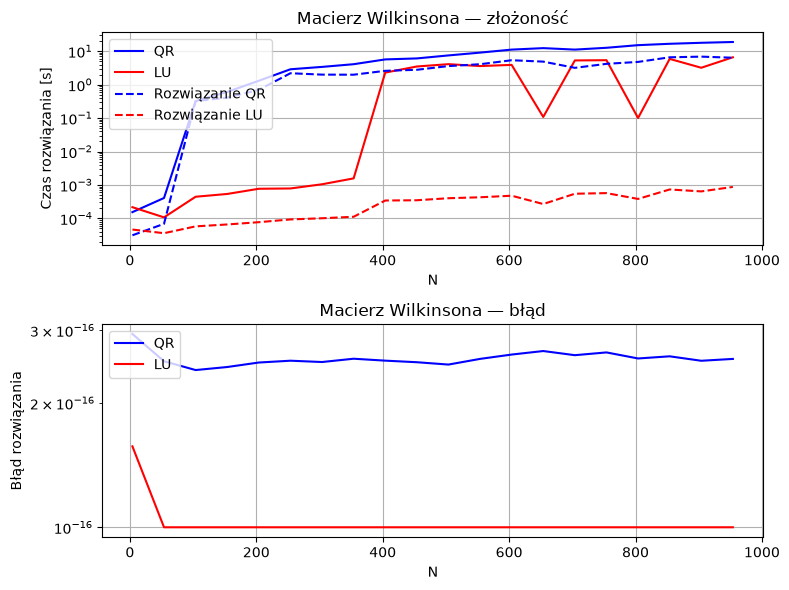

In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt

Nmax = 300
step = 50

bladQR_W = []; bladLU_W = []
zlozonoscQR_W = []; zlozonoscLU_W = []
zlozonoscRozwQR_W = []; zlozonoscRozwLU_W = []
sizesW = []

print("Rozwiązywanie z macierzą Wilkinsona... (to może trwać ~30s)")
T0 = time.perf_counter()
for i in range(4, Nmax + 1, step):
    A = wilkinson(i)
    b = A.sum(axis=1)
    time_all_qr, time_simple_qr, error_qr = solveUsingQRFactorization(A, b)
    bladQR_W.append(error_qr)
    zlozonoscRozwQR_W.append(time_simple_qr)
    zlozonoscQR_W.append(time_all_qr)
    sizesW.append(i)
    time_all_lu, time_simple_lu, error_lu = solveUsingLUFactorization(A, b)
    bladLU_W.append(error_lu)
    zlozonoscLU_W.append(time_all_lu)
    zlozonoscRozwLU_W.append(time_simple_lu)
    if i % 10 == 0:
        elapsed = time.perf_counter() - T0
        print(f"  N={i:4d}/{Nmax}  ({elapsed:.1f}s)")

print(f"Gotowe! Całkowity czas: {time.perf_counter()-T0:.1f}s")

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].set_yscale('log')
axes[0].plot(sizesW, zlozonoscQR_W, 'b', label='QR')
axes[0].plot(sizesW, zlozonoscLU_W, 'r', label='LU')
axes[0].plot(sizesW, zlozonoscRozwQR_W, '--b', label='Rozwiązanie QR')
axes[0].plot(sizesW, zlozonoscRozwLU_W, '--r', label='Rozwiązanie LU')
axes[0].set_xlabel('N')
axes[0].set_ylabel('Czas rozwiązania [s]')
axes[0].grid(True)
axes[0].legend(loc='upper left')
axes[0].set_title('Macierz Wilkinsona — złożoność')

axes[1].semilogy(sizesW, [max(e, 1e-16) for e in bladQR_W], 'b', label='QR')
axes[1].semilogy(sizesW, [max(e, 1e-16) for e in bladLU_W], 'r', label='LU')
axes[1].set_xlabel('N')
axes[1].set_ylabel('Błąd rozwiązania')
axes[1].grid(True)
axes[1].legend(loc='upper left')
axes[1].set_title('Macierz Wilkinsona — błąd')

plt.tight_layout()
plt.show()


## Wykorzystywane funkcje

W rozkładzie QR układ $Ax=b$ przekształcamy do $Rx = Q^T b$, ponieważ macierz $Q$ jest ortonormalna ($Q^T Q = I$). Operacja `y = Q.T @ b` odpowiada przemnożeniu prawej strony przez $Q^T$.

| Funkcja | Opis |
|---------|------|
| `np.linalg.qr(A)` | Oblicza rozkład QR macierzy A |
| `scipy.linalg.lu_factor(A)` | Oblicza rozkład LU macierzy A z pivotowaniem |
| `scipy.linalg.lu_solve((lu, piv), b)` | Rozwiązuje układ A*x=b używając rozkładu LU |
| `np.linalg.solve(R, y)` | Rozwiązuje układ liniowy R*x=y |
| `np.linalg.norm(x)` | Oblicza normę euklidesową wektora |
| `np.random.rand(n, n)` | Generuje losową macierz n×n z rozkładu jednostajnego |
| `time.perf_counter()` | Zwraca czas procesora o wysokiej rozdzielczości |
| `wilkinson(n)` | Generuje macierz Wilkinsona rozmiaru n×n |
